## 1) Use a Wikipedia article as dataset

In [ ]:
import random
import re
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import nltk
import numpy as np
from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

DATASET_PATH = Path("wikiArticle_1963_Atlantic_hurricane_season.md")
RANDOM_SEED = 42
VECTOR_SIZE = 100
BASELINE_WINDOW = 5
UPDATED_WINDOW = 10
MIN_COUNT = 1
EPOCHS = 150
TOPN_NEIGHBORS = 8


def ensure_nltk() -> None:
    resources = ["punkt", "punkt_tab"]
    for resource in resources:
        try:
            nltk.data.find(f"tokenizers/{resource}")
        except LookupError:
            nltk.download(resource)


def load_dataset(path: Path) -> str:
    if not path.exists():
        raise FileNotFoundError(f"Dataset file not found: {path}")
    return path.read_text(encoding="utf-8", errors="ignore")


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
ensure_nltk()

raw_text = load_dataset(DATASET_PATH)
print("Dataset loaded:", DATASET_PATH)
print("Raw character count:", len(raw_text))

Dataset loaded: wikiArticle_1963_Atlantic_hurricane_season.md
Raw character count: 74341


## 2) Preprocess the text

In [ ]:
def strip_markdown_noise(text: str) -> str:
    cleaned = text
    cleaned = re.sub(r"```.*?```", " ", cleaned, flags=re.DOTALL)
    cleaned = re.sub(r"`[^`]*`", " ", cleaned)

    cleaned = re.sub(r"!\[[^\]]*\]\([^)]*\)", " ", cleaned)
    cleaned = re.sub(r"\[!\[[^\]]*\]\([^)]*\)\]\([^)]*\)", " ", cleaned)
    cleaned = re.sub(r"\(//upload\.wikimedia\.org[^)]+\)", " ", cleaned)

    cleaned = re.sub(r"\[([^\]]+)\]\([^)]*\)", r" \1 ", cleaned)
    cleaned = re.sub(r"https?://\S+", " ", cleaned)
    cleaned = re.sub(r"//\S+", " ", cleaned)

    cleaned = re.sub(r"\[\\?\[\d+\\?\]\]", " ", cleaned)
    cleaned = re.sub(r"\[\d+\]", " ", cleaned)
    cleaned = re.sub(r"\^\s*\d+", " ", cleaned)

    cleaned = re.sub(r"\{\{[^}]*\}\}", " ", cleaned)
    cleaned = re.sub(r"\[edit\]|edit section|main article", " ", cleaned, flags=re.IGNORECASE)
    cleaned = re.sub(r"^\s{0,3}#{1,6}\s*", " ", cleaned, flags=re.MULTILINE)
    cleaned = re.sub(r"^\s*[-*+]\s+", " ", cleaned, flags=re.MULTILINE)
    cleaned = re.sub(r"\|", " ", cleaned)

    cleaned = re.sub(r"[^a-zA-Z0-9\s\.,;:!?'-]", " ", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned


def preprocess_text(text: str) -> List[List[str]]:
    sents = sent_tokenize(text)
    processed: List[List[str]] = []

    for sent in sents:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)
        cleaned_tokens = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok or tok.isdigit() or len(tok) < 2:
                continue
            cleaned_tokens.append(tok)

        if len(cleaned_tokens) >= 3:
            processed.append(cleaned_tokens)

    return processed


def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(set(flat)),
    }

cleaned_text = strip_markdown_noise(raw_text)
sentences = preprocess_text(cleaned_text)
stats = corpus_stats(sentences)

print("Corpus stats:", stats)

Corpus stats: {'num_sentences': 318, 'num_tokens': 5181, 'vocab_size': 1124}


## 3) Train Skip-gram with Negative Sampling

In [ ]:
def train_sgns(sentences: List[List[str]], window: int) -> Word2Vec:
    return Word2Vec(
        sentences=sentences,
        vector_size=VECTOR_SIZE,
        window=window,
        min_count=MIN_COUNT,
        workers=4,
        sg=1,
        negative=10,
        epochs=EPOCHS,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )

model_w5 = train_sgns(sentences, window=BASELINE_WINDOW)
model_w10 = train_sgns(sentences, window=UPDATED_WINDOW)

print("Vocabulary size:", len(model_w10.wv))
print("Training complete for both models (window=5 and window=10).")

Vocabulary size: 1124
Training complete for both models (window=5 and window=10).


## 4) Evaluate embeddings using a small test set

In [ ]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]) -> Dict[str, object]:
    covered_items = []
    for w1, w2, gold in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            pred = cosine(model, w1, w2)
            covered_items.append((w1, w2, gold, pred))
    return {"covered_items": covered_items, "coverage": len(covered_items), "total": len(test_pairs)}


def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]) -> Dict[str, object]:
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
            pred_words = [w for w, _ in preds]
            hit = d in pred_words
            correct += int(hit)
            details.append({"analogy": f"{a}:{b}::{c}:?", "expected": d, "predictions": pred_words, "correct_in_top5": hit})

    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": (correct / covered) if covered else float("nan"),
        "details": details,
    }


def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = TOPN_NEIGHBORS):
    for w in words:
        if has_word(model, w):
            print(f"\n{w}:")
            for n, s in model.wv.most_similar(w, topn=topn):
                print(f"  {n:20s} {s:.4f}")
        else:
            print(f"\n{w}: [OOV]")


def evaluate_model(model: Word2Vec, label: str):
    print(f"\n===== {label} =====")

    probe_words = ["hurricane", "storm", "winds", "rainfall", "damage", "deaths", "cuba", "bahamas", "atlantic", "season"]
    print_top_neighbors(model, probe_words, topn=TOPN_NEIGHBORS)

    relatedness_test = [
        ("hurricane", "storm", 0.95),
        ("rainfall", "flooding", 0.90),
        ("winds", "damage", 0.75),
        ("cuba", "bahamas", 0.55),
        ("atlantic", "season", 0.70),
        ("hurricane", "kitchen", 0.05),
        ("storm", "banana", 0.10),
        ("deaths", "damage", 0.50),
    ]

    analogy_test = [
        ("hurricane", "winds", "storm", "rainfall"),
        ("cuba", "caribbean", "bahamas", "atlantic"),
        ("season", "storms", "hurricane", "winds"),
        ("flooding", "damage", "rainfall", "deaths"),
    ]

    rel = evaluate_relatedness(model, relatedness_test)
    an = evaluate_analogies(model, analogy_test)

    print("\nRelatedness coverage:", f"{rel['coverage']}/{rel['total']}")
    print("Analogy top-5 accuracy:", an["accuracy_top5"])

    check_pairs = [("hurricane", "storm"), ("rainfall", "flooding"), ("cuba", "bahamas"), ("hurricane", "kitchen")]
    pair_scores = {}
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            pair_scores[f"{w1}|{w2}"] = cosine(model, w1, w2)
        else:
            pair_scores[f"{w1}|{w2}"] = None

    return {"relatedness": rel, "analogies": an, "pair_scores": pair_scores}

baseline_results = evaluate_model(model_w5, "OLD model (window=5)")
updated_results = evaluate_model(model_w10, "NEW model (window=10)")


===== OLD model (window=5) =====

hurricane:
  ts                   0.5005
  languages            0.4451
  nederlands           0.4390
  administration       0.4387
  british              0.4370
  isles                0.4299
  c1                   0.4297
  note-9               0.4256

storm:
  note-canada-34       0.5394
  note-8               0.5040
  cyclogenesis         0.4792
  within               0.4725
  month                0.4652
  soon                 0.4603
  north-northwestward  0.4578
  east-northeastward   0.4480

winds:
  strong               0.5205
  minimum              0.5073
  measured             0.5066
  plane                0.5035
  found                0.4998
  afternoon            0.4951
  hurricane-force      0.4899
  navy                 0.4876

rainfall:
  heavy                0.8115
  setting              0.6884
  24-hour              0.6797
  daily                0.6766
  dropped              0.6712
  santiago             0.6664
  reaching             0.66

## 5) Report nearest neighbors, similarity scores, and test-set performance

In [ ]:
def compare_window_results(old_result: Dict[str, object], new_result: Dict[str, object]):
    print("Window comparison: OLD (5) vs NEW (10)")
    old_cov = old_result["relatedness"]["coverage"]
    new_cov = new_result["relatedness"]["coverage"]
    print(f"Relatedness coverage: old={old_cov} new={new_cov}")

    old_acc = old_result["analogies"]["accuracy_top5"]
    new_acc = new_result["analogies"]["accuracy_top5"]
    print(f"Analogy top-5 accuracy: old={old_acc} new={new_acc}")

    print("\nPair similarity deltas (new - old):")
    for pair, old_score in old_result["pair_scores"].items():
        new_score = new_result["pair_scores"].get(pair)
        if old_score is None or new_score is None:
            print(f"  {pair}: OOV in one of the models")
        else:
            delta = new_score - old_score
            print(f"  {pair}: {delta:+.4f} (old={old_score:.4f}, new={new_score:.4f})")

compare_window_results(baseline_results, updated_results)

model_w5.save("exercise_5_skipgram_window5.model")
model_w10.save("exercise_5_skipgram_window10.model")
print("\nSaved models: exercise_5_skipgram_window5.model, exercise_5_skipgram_window10.model")

Window comparison: OLD (5) vs NEW (10)
Relatedness coverage: old=7 new=7
Analogy top-5 accuracy: old=0.0 new=0.0

Pair similarity deltas (new - old):
  hurricane|storm: -0.0489 (old=0.3099, new=0.2610)
  rainfall|flooding: +0.0101 (old=0.2688, new=0.2789)
  cuba|bahamas: -0.0420 (old=0.4215, new=0.3795)
  hurricane|kitchen: OOV in one of the models

Saved models: exercise_5_skipgram_window5.model, exercise_5_skipgram_window10.model


## Update 1) Retrain Word2Vec with window size 10

**Exact item represented by code:**
- OLD model: `window=5`
- NEW model: `window=10`

**OLD:** baseline_results (window=5)

**NEW:** updated_results (window=10)

**Answer (student-style comparison):**
Based on my run, changing the window to 10 did not improve everything at once.  
Some pair similarities got a little better (like rainfall-flooding), while others got lower (like hurricane-storm).  
This means a wider context can help some word relations, but on a single-article dataset it can also make some specific relations less sharp.

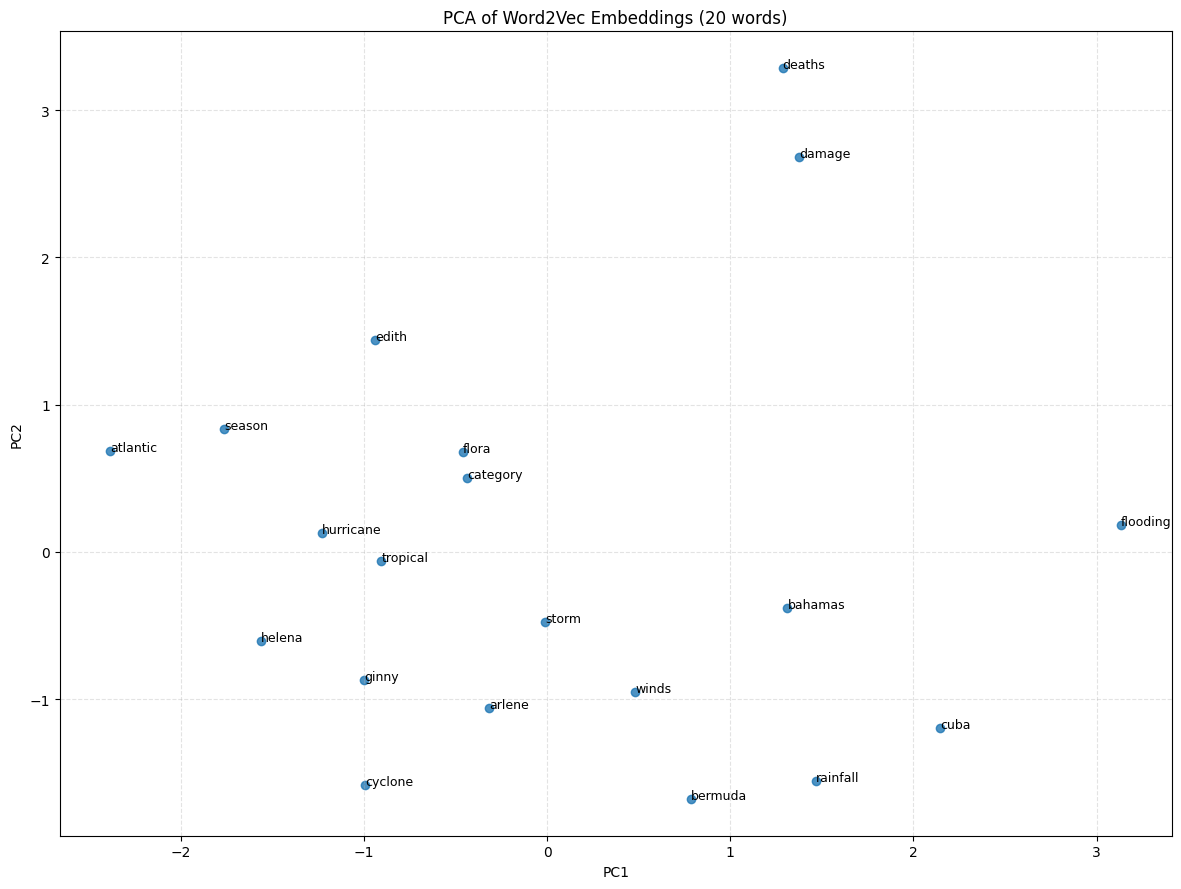

PCA words used:
hurricane, storm, atlantic, season, winds, rainfall, flooding, damage, deaths, cuba, bahamas, bermuda, tropical, cyclone, category, flora, edith, ginny, helena, arlene


In [10]:
def plot_pca(model: Word2Vec, candidate_words: List[str], output_path: Path):
    available = [w for w in candidate_words if has_word(model, w)]

    if len(available) < 20:
        for word in model.wv.key_to_index.keys():
            if word not in available:
                available.append(word)
            if len(available) >= 20:
                break

    selected = available[:20]
    vectors = np.array([model.wv[w] for w in selected])

    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    points = pca.fit_transform(vectors)

    plt.figure(figsize=(12, 9))
    plt.scatter(points[:, 0], points[:, 1], alpha=0.8)
    for i, word in enumerate(selected):
        plt.annotate(word, (points[i, 0], points[i, 1]), fontsize=9)

    plt.title("PCA of Word2Vec Embeddings (20 words)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.savefig(output_path, dpi=180)
    plt.show()

    print("PCA words used:")
    print(", ".join(selected))


pca_candidates = [
    "hurricane", "storm", "atlantic", "season", "winds",
    "rainfall", "flooding", "damage", "deaths", "cuba",
    "bahamas", "bermuda", "tropical", "cyclone", "category",
    "flora", "edith", "ginny", "helena", "arlene",
    "beulah", "debra", "islands", "caribbean", "pressure",
]

plot_pca(model_w10, pca_candidates, Path("exercise_5_pca_window10.png"))

**Retrain the Word2Vec model with the following configuration:**
Window size of 10

**Compare the evaluation values to the previous model. What can you derive from the change?**

**OLD:**
The old model used a window size of 5. It gave more focused local relationships between words, so some pairs looked stronger in a smaller context.

**NEW:**
The new model used a window size of 10. It looked at a wider context, so it captured broader word relationships, but some values became less sharp.

**What I derived from the change:**
From my comparison, the larger window did not improve every result. It helped the model learn more surrounding context, but on this dataset it also made some specific word relationships weaker. So, I think window size 10 gives broader meaning, while window size 5 gives tighter local similarity.